Loading data for Global Moran's I analysis...
Calculating Global Moran's I for each year (2000-2024) with KNN (k=6)...
Year 2000: Moran's I = 0.3732, p-value = 0.0010
Year 2005: Moran's I = 0.3093, p-value = 0.0010
Year 2010: Moran's I = 0.2850, p-value = 0.0010
Year 2015: Moran's I = 0.3118, p-value = 0.0010


c:\Users\jr\miniconda3\envs\geo\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 19 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\jr\miniconda3\envs\geo\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\jr\miniconda3\envs\geo\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 17 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\jr\miniconda3\envs\geo\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 22 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\jr\miniconda3\envs\geo\Lib\site-packages\libpysal\weigh

Year 2020: Moran's I = 0.3669, p-value = 0.0010
Year 2024: Moran's I = 0.3182, p-value = 0.0010

Plotting Global Moran's I trend with enhanced aesthetics...
Global Moran's I trend plot saved to global_moran_I_mhi_trend_v2.png


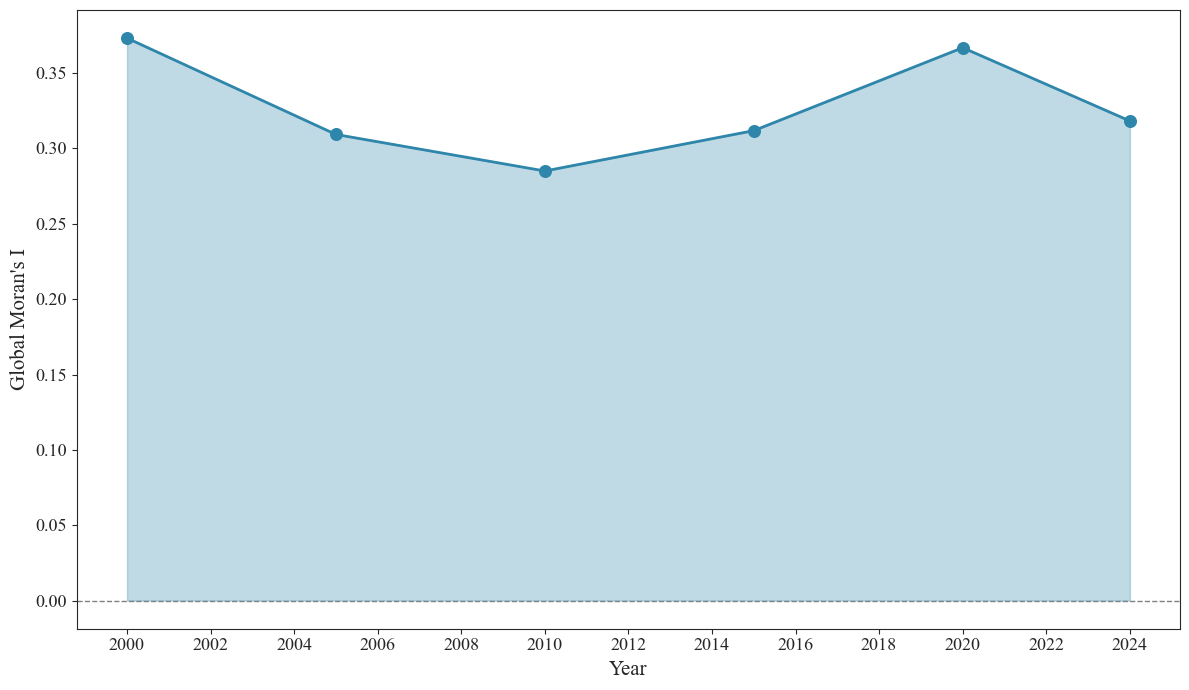

In [1]:
import pandas as pd
import geopandas as gpd
import libpysal
from esda.moran import Moran
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def global_moran_analysis():
    """
    Calculates and plots the Global Moran's I for MHI for each year from 2000-2024,
    using a KNN (k=6) spatial weights matrix, with enhanced aesthetics for publication.
    """
    print("Loading data for Global Moran's I analysis...")
    sns.set_style("ticks")
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams['axes.labelsize'] = 15
    plt.rcParams['axes.titlesize'] = 16
    try:
        df = pd.read_csv('final_environment_with_MHI.csv', usecols=['GridID', 'year', 'MHI'])
    except FileNotFoundError:
        print("Error: final_environment_with_MHI.csv not found.")
        return

    try:
        gdf_shape = gpd.read_file('buffer/mangrove_2020_500m_hex_grid.shp')
    except Exception as e:
        print(f"Error loading shapefile: {e}")
        return

    gdf_shape['GridID'] = gdf_shape['GridID'].astype(df['GridID'].dtype)

    years = range(2000, 2025)
    moran_results = []

    print("Calculating Global Moran's I for each year (2000-2024) with KNN (k=6)...")
    for year in years:
        df_year = df[df['year'] == year]
        if df_year.empty: continue
            
        gdf_year = gdf_shape.merge(df_year, on='GridID')
        gdf_year.dropna(subset=['MHI'], inplace=True)
        if gdf_year.empty: continue
            
        w = libpysal.weights.KNN.from_dataframe(gdf_year, k=6)
        w.transform = 'r'
        
        moran = Moran(gdf_year['MHI'], w)
        
        moran_results.append({'year': year, 'moran_I': moran.I, 'p_value': moran.p_sim})
        print(f"Year {year}: Moran's I = {moran.I:.4f}, p-value = {moran.p_sim:.4f}")

    if not moran_results:
        print("No Moran's I results were calculated. Aborting plot.")
        return

    results_df = pd.DataFrame(moran_results)

    # --- Plotting with Enhanced Aesthetics ---
    print("\nPlotting Global Moran's I trend with enhanced aesthetics...")
    
    fig, ax = plt.subplots(figsize=(12, 7))

    # Define a consistent color scheme
    main_color = '#2E86AB'  # Deep blue color
    
    # Plot the line and fill underneath with the same color
    ax.plot(results_df['year'], results_df['moran_I'], marker='', linestyle='-', color=main_color, lw=2, label="Moran's I")
    ax.fill_between(results_df['year'], results_df['moran_I'], color=main_color, alpha=0.3)

    sig = results_df[results_df['p_value'] < 0.05]
    non_sig = results_df[results_df['p_value'] >= 0.05]

    # Use the same color for significant points
    ax.scatter(sig['year'], sig['moran_I'], color=main_color, s=70, zorder=5, label='Significant (p < 0.05)')
    # Use white fill with same color edge for non-significant points
    ax.scatter(non_sig['year'], non_sig['moran_I'], facecolors='white', edgecolors=main_color, s=70, linewidths=1.5, zorder=5, label='Not Significant (p ≥ 0.05)')

    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('Year', fontsize=15)
    ax.set_ylabel("Global Moran's I", fontsize=15)

    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.grid(False)
    # Adjust legend

    
    plt.xticks(np.arange(min(years), max(years)+1, 2))
    plt.tight_layout()

    output_path = 'global_moran_I_mhi_trend_v2.png'
    plt.savefig(output_path, dpi=300)
    print(f"Global Moran's I trend plot saved to {output_path}")
    plt.show()

if __name__ == '__main__':
    global_moran_analysis()